# Independent Samples t-Test: Titanic Fare Analysis

## Introduction

An independent samples t-test is a statistical hypothesis test used to determine whether the means of two independent groups are significantly different.

In this project, the Titanic dataset is used to compare the average fare paid by male and female passengers.

## Objective

The objective is to determine whether there is a statistically significant difference in the average fare paid by the two groups.

## Research Question

Is there a statistically significant difference between the average fare paid by male and female Titanic passengers?

## Null Hypothesis (H₀)

There is no statistically significant difference between the average fare paid by male and female passengers.

H₀: μ_male = μ_female

## Alternative Hypothesis (H₁)

There is a statistically significant difference between the average fare paid by male and female passengers.

H₁: μ_male ≠ μ_female

## Significance Level

The significance level is set to α = 0.05.

## Method

A Welch independent samples t-test is used because it does not require the two groups to have equal population variances.

In [1]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Load Titanic dataset

df = sns.load_dataset("titanic")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [3]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [4]:
print("Shape:", df.shape)

Shape: (891, 15)


In [5]:
print(df.columns)

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='object')


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [7]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [8]:
df.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,177
sibsp,0
parch,0
fare,0
embarked,2
class,0
who,0


In [9]:
# Select variables needed for our analysis

data = df[['sex', 'fare']].copy()

data.head()

,sex,fare
0,male,7.2500
1,female,71.2833
2,female,7.9250
3,female,53.1000
4,male,8.0500


In [10]:
data.isnull().sum()

,0
sex,0
fare,0


In [11]:
data = data.dropna()

print("Dataset after removing missing values:")
print(data.shape)

Dataset after removing missing values:
(891, 2)


In [12]:
print(data['sex'].value_counts())

sex
male      577
female    314
Name: count, dtype: int64


In [13]:
group_summary = data.groupby('sex')['fare'].agg(
    ['count', 'mean', 'median', 'std']
)

group_summary

,count,mean,median,std
sex,,,,
female,314,44.479818,23.0,57.997698
male,577,25.523893,10.5,43.138263


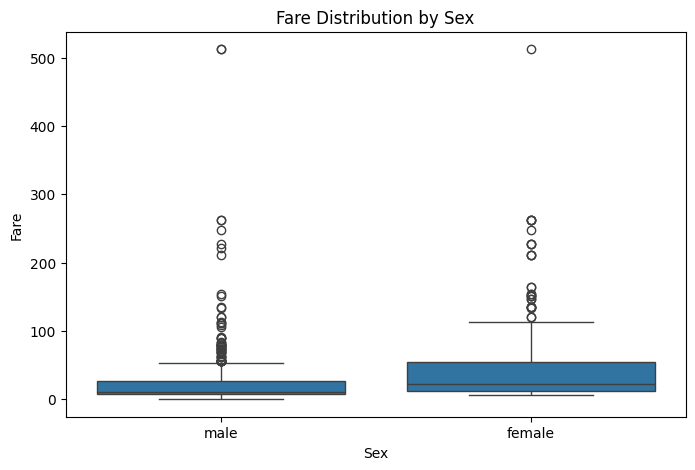

In [14]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=data,
    x='sex',
    y='fare'
)

plt.title('Fare Distribution by Sex')
plt.xlabel('Sex')
plt.ylabel('Fare')

plt.show()

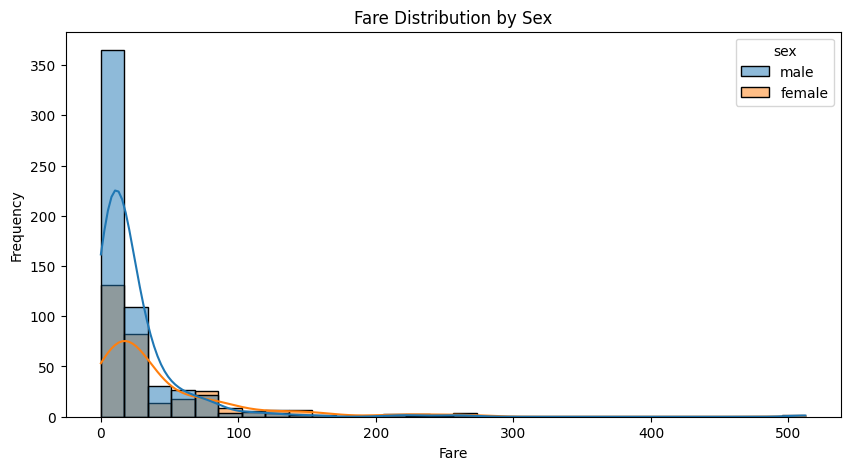

In [15]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=data,
    x='fare',
    hue='sex',
    kde=True,
    bins=30
)

plt.title('Fare Distribution by Sex')
plt.xlabel('Fare')
plt.ylabel('Frequency')

plt.show()

In [16]:
print("Overall Fare Skewness:", data['fare'].skew())

print("\nMale Fare Skewness:",
      data[data['sex'] == 'male']['fare'].skew())

print("\nFemale Fare Skewness:",
      data[data['sex'] == 'female']['fare'].skew())

Overall Fare Skewness: 4.787316519674893

Male Fare Skewness: 6.62151491617816

Female Fare Skewness: 3.2776225699972397


In [17]:
male_fare = data[data['sex'] == 'male']['fare']

female_fare = data[data['sex'] == 'female']['fare']

print("Male observations:", len(male_fare))
print("Female observations:", len(female_fare))

Male observations: 577
Female observations: 314


In [18]:
print("Male mean fare:", male_fare.mean())
print("Female mean fare:", female_fare.mean())

Male mean fare: 25.523893414211443
Female mean fare: 44.47981783439491


In [19]:
t_stat, p_value = stats.ttest_ind(
    male_fare,
    female_fare,
    equal_var=False,
    alternative='two-sided'
)

print("t-statistic:", t_stat)
print("p-value:", p_value)

t-statistic: -5.077499013458909
p-value: 5.388057409693902e-07


In [20]:
alpha = 0.05

In [21]:
alpha = 0.05

if p_value < alpha:
    print("Reject the null hypothesis.")
    print("There is a statistically significant difference between the group means.")
else:
    print("Fail to reject the null hypothesis.")
    print("There is not enough evidence to conclude that the group means are significantly different.")

Reject the null hypothesis.
There is a statistically significant difference between the group means.


In [22]:
mean_difference = female_fare.mean() - male_fare.mean()

print("Mean difference:", mean_difference)

Mean difference: 18.955924420183464


In [23]:
n1 = len(female_fare)
n2 = len(male_fare)

mean1 = female_fare.mean()
mean2 = male_fare.mean()

var1 = female_fare.var()
var2 = male_fare.var()

se = np.sqrt((var1/n1) + (var2/n2))

df_welch = ((var1/n1 + var2/n2)**2) / (
    ((var1/n1)**2)/(n1-1) +
    ((var2/n2)**2)/(n2-1)
)

critical_value = stats.t.ppf(0.975, df_welch)

lower = mean1 - mean2 - critical_value * se
upper = mean1 - mean2 + critical_value * se

print("95% Confidence Interval:")
print("Lower:", lower)
print("Upper:", upper)

95% Confidence Interval:
Lower: 11.621173142691497
Upper: 26.290675697675432


In [24]:
# Cohen's d

pooled_std = np.sqrt(
    ((n1 - 1) * var1 + (n2 - 1) * var2) /
    (n1 + n2 - 2)
)

cohens_d = (mean1 - mean2) / pooled_std

print("Cohen's d:", cohens_d)

Cohen's d: 0.38774278839925935


In [25]:
results = pd.DataFrame({
    'Group': ['Female', 'Male'],
    'Sample Size': [n1, n2],
    'Mean Fare': [mean1, mean2],
    'Standard Deviation': [
        female_fare.std(),
        male_fare.std()
    ]
})

results

,Group,Sample Size,Mean Fare,Standard Deviation
0,Female,314,44.479818,57.997698
1,Male,577,25.523893,43.138263


In [26]:
print("Independent Samples t-Test")
print("--------------------------------")
print("t-statistic:", round(t_stat, 4))
print("p-value:", round(p_value, 6))
print("Mean difference:", round(mean_difference, 4))
print("Cohen's d:", round(cohens_d, 4))
print("Significance level:", alpha)

Independent Samples t-Test
--------------------------------
t-statistic: -5.0775
p-value: 1e-06
Mean difference: 18.9559
Cohen's d: 0.3877
Significance level: 0.05


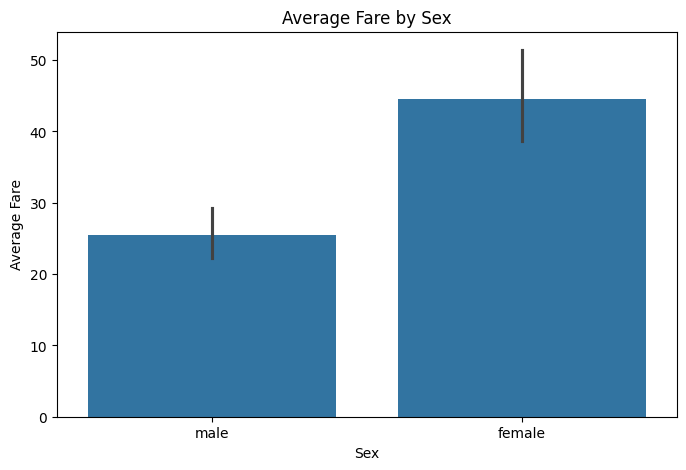

In [27]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=data,
    x='sex',
    y='fare',
    errorbar='ci'
)

plt.title('Average Fare by Sex')
plt.xlabel('Sex')
plt.ylabel('Average Fare')

plt.show()

## Conclusion

An independent samples Welch's t-test was conducted to compare the average fare paid by male and female Titanic passengers.

The test produced a t-statistic of -5.0775 and a p-value of 0.000001. Since the p-value is much smaller than the significance level of 0.05, the null hypothesis was rejected.

Therefore, there is statistically significant evidence that the average fare paid by male and female passengers differs.

The mean fare difference (Female − Male) was approximately 18.96, indicating that female passengers paid a higher average fare in this dataset.

The Cohen's d effect size was 0.3877, indicating a small-to-moderate practical effect.

Overall, the analysis demonstrates that the difference in average fares between male and female passengers is statistically significant, although the effect size suggests that the magnitude of the difference is not very large.